In [12]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Download data
tickers = ["GC=F", "EURUSD=X"]
df = yf.download(tickers, start="2022-01-01", end="2024-12-31", group_by="ticker")

# Flatten column names
df.columns = ['_'.join(col).strip() for col in df.columns.values]
print(df.columns)
print(df.shape)
df.head()

C:\Users\Manish Chaudhary\AppData\Local\Temp\ipykernel_6204\523426329.py:8: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(tickers, start="2022-01-01", end="2024-12-31", group_by="ticker")
[*********************100%***********************]  2 of 2 completed

Index(['EURUSD=X_Open', 'EURUSD=X_High', 'EURUSD=X_Low', 'EURUSD=X_Close',
       'EURUSD=X_Volume', 'GC=F_Open', 'GC=F_High', 'GC=F_Low', 'GC=F_Close',
       'GC=F_Volume'],
      dtype='object')
(781, 10)


,EURUSD=X_Open,EURUSD=X_High,EURUSD=X_Low,EURUSD=X_Close,EURUSD=X_Volume,GC=F_Open,GC=F_High,GC=F_Low,GC=F_Close,GC=F_Volume
Date,,,,,,,,,,
2022-01-03,1.137385,1.137592,1.128541,1.137346,0,1830.099976,1830.099976,1798.800049,1799.400024,116.0
2022-01-04,1.130199,1.132300,1.127345,1.130224,0,1800.500000,1815.300049,1800.000000,1814.000000,38.0
2022-01-05,1.128541,1.134559,1.127764,1.128363,0,1813.099976,1824.599976,1813.099976,1824.599976,8.0
2022-01-06,1.131222,1.133067,1.128554,1.131350,0,1787.099976,1791.300049,1787.099976,1788.699951,30.0
2022-01-07,1.129586,1.135976,1.129050,1.129688,0,1791.800049,1797.000000,1784.400024,1797.000000,17.0


In [13]:
df.describe()

,EURUSD=X_Open,EURUSD=X_High,EURUSD=X_Low,EURUSD=X_Close,EURUSD=X_Volume,GC=F_Open,GC=F_High,GC=F_Low,GC=F_Close,GC=F_Volume
count,781.000000,781.000000,781.000000,781.000000,781.0,752.000000,752.000000,752.000000,752.000000,752.000000
mean,1.072635,1.076098,1.068958,1.072636,0.0,2043.692419,2053.330719,2034.801595,2044.098135,4077.969415
std,0.034695,0.034024,0.035190,0.034697,0.0,289.509420,290.980806,287.730291,289.520326,21999.206142
min,0.959619,0.967006,0.954016,0.959619,0.0,1620.400024,1623.300049,1615.099976,1623.300049,0.000000
25%,1.056747,1.060502,1.052920,1.056747,0.0,1838.300018,1843.074982,1829.650024,1839.850006,63.000000
50%,1.079354,1.082204,1.076299,1.079354,0.0,1953.900024,1963.200012,1945.599976,1955.949951,210.500000
75%,1.092813,1.095446,1.089871,1.092813,0.0,2259.424988,2284.099976,2252.550049,2267.950012,601.000000
max,1.145659,1.149425,1.143641,1.145712,0.0,2787.399902,2789.000000,2774.600098,2788.500000,202373.000000


In [14]:
df.isnull().sum()

EURUSD=X_Open       0
EURUSD=X_High       0
EURUSD=X_Low        0
EURUSD=X_Close      0
EURUSD=X_Volume     0
GC=F_Open          29
GC=F_High          29
GC=F_Low           29
GC=F_Close         29
GC=F_Volume        29
dtype: int64

In [15]:
df[df.isna().any(axis=1)]

,EURUSD=X_Open,EURUSD=X_High,EURUSD=X_Low,EURUSD=X_Close,EURUSD=X_Volume,GC=F_Open,GC=F_High,GC=F_Low,GC=F_Close,GC=F_Volume
Date,,,,,,,,,,
2022-01-17,1.141214,1.143458,1.139315,1.141070,0,NaN,NaN,NaN,NaN,NaN
2022-02-21,1.131734,1.138563,1.131414,1.131721,0,NaN,NaN,NaN,NaN,NaN
2022-04-15,1.082099,1.082345,1.079879,1.082099,0,NaN,NaN,NaN,NaN,NaN
2022-05-30,1.073146,1.078516,1.072743,1.073146,0,NaN,NaN,NaN,NaN,NaN
2022-06-20,1.049142,1.054519,1.048636,1.049142,0,NaN,NaN,NaN,NaN,NaN
2022-07-04,1.043395,1.046353,1.041808,1.043395,0,NaN,NaN,NaN,NaN,NaN
2022-09-05,0.990943,0.994352,0.988084,0.990943,0,NaN,NaN,NaN,NaN,NaN
2022-11-24,1.041623,1.044823,1.038368,1.041623,0,NaN,NaN,NaN,NaN,NaN
2022-12-26,1.066780,1.063717,1.060895,1.066780,0,NaN,NaN,NaN,NaN,NaN


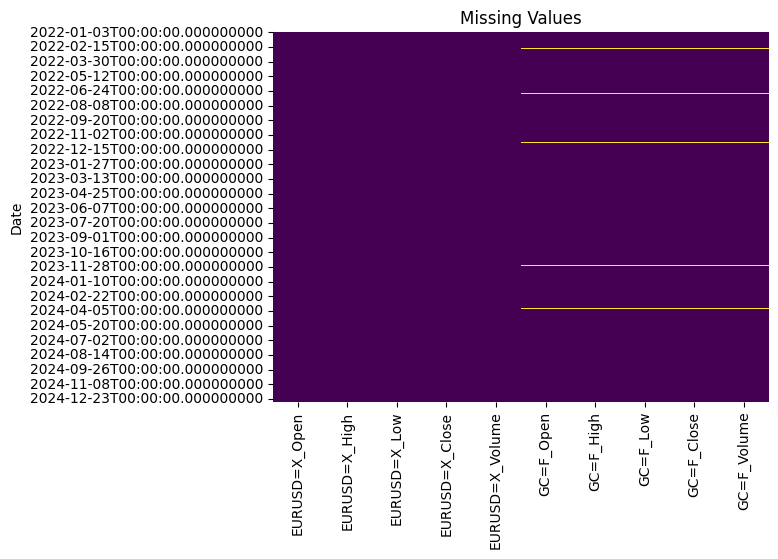

In [16]:
sns.heatmap(df.isna(), cbar = False, cmap="viridis")
plt.title("Missing Values")
plt.show()

In [17]:
print(df.shape)
df.dropna(inplace=True)
print(df[df.isna().any(axis=1)])
df.drop(["EURUSD=X_Volume","GC=F_Volume"],axis=1, inplace = True)
print(df.shape)
df.head()

(781, 10)
Empty DataFrame
Columns: [EURUSD=X_Open, EURUSD=X_High, EURUSD=X_Low, EURUSD=X_Close, EURUSD=X_Volume, GC=F_Open, GC=F_High, GC=F_Low, GC=F_Close, GC=F_Volume]
Index: []
(752, 8)


,EURUSD=X_Open,EURUSD=X_High,EURUSD=X_Low,EURUSD=X_Close,GC=F_Open,GC=F_High,GC=F_Low,GC=F_Close
Date,,,,,,,,
2022-01-03,1.137385,1.137592,1.128541,1.137346,1830.099976,1830.099976,1798.800049,1799.400024
2022-01-04,1.130199,1.132300,1.127345,1.130224,1800.500000,1815.300049,1800.000000,1814.000000
2022-01-05,1.128541,1.134559,1.127764,1.128363,1813.099976,1824.599976,1813.099976,1824.599976
2022-01-06,1.131222,1.133067,1.128554,1.131350,1787.099976,1791.300049,1787.099976,1788.699951
2022-01-07,1.129586,1.135976,1.129050,1.129688,1791.800049,1797.000000,1784.400024,1797.000000


In [18]:
df.describe()

,EURUSD=X_Open,EURUSD=X_High,EURUSD=X_Low,EURUSD=X_Close,GC=F_Open,GC=F_High,GC=F_Low,GC=F_Close
count,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000,752.000000
mean,1.072433,1.075948,1.068689,1.072434,2043.692419,2053.330719,2034.801595,2044.098135
std,0.034903,0.034217,0.035392,0.034905,289.509420,290.980806,287.730291,289.520326
min,0.959619,0.967006,0.954016,0.959619,1620.400024,1623.300049,1615.099976,1623.300049
25%,1.056697,1.060243,1.052823,1.056697,1838.300018,1843.074982,1829.650024,1839.850006
50%,1.079360,1.082251,1.076229,1.079360,1953.900024,1963.200012,1945.599976,1955.949951
75%,1.092893,1.095575,1.089894,1.092893,2259.424988,2284.099976,2252.550049,2267.950012
max,1.145659,1.149425,1.143641,1.145712,2787.399902,2789.000000,2774.600098,2788.500000


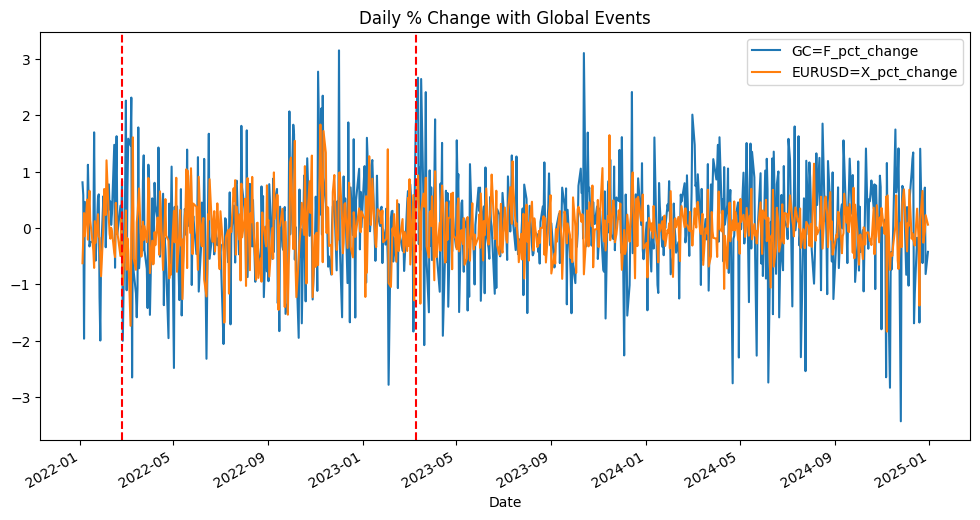

In [19]:
df['GC=F_pct_change']=df['GC=F_Close'].pct_change()*100
df['EURUSD=X_pct_change']=df['EURUSD=X_Close'].pct_change()*100
df[['GC=F_pct_change','EURUSD=X_pct_change']].plot(figsize=(12,6),title = 'Daily % Change with Global Events')
for date in ['2022-02-24', '2023-03-10']:
    plt.axvline(pd.to_datetime(date), color = 'red', linestyle ='--')

In [22]:
#flight to safety
flight_days = df[(df['GC=F_pct_change']>0) & (df['EURUSD=X_pct_change']<0)]
print("Number of flight to safety days",flight_days.shape[0])
flight_days[['GC=F_pct_change','EURUSD=X_pct_change']].head()

Number of flight to safety days 204


,GC=F_pct_change,EURUSD=X_pct_change
Date,,
2022-01-04,0.811380,-0.626146
2022-01-05,0.584343,-0.164740
2022-01-07,0.464027,-0.146863
2022-01-11,1.123218,-0.207352
2022-01-19,1.699494,-0.709233


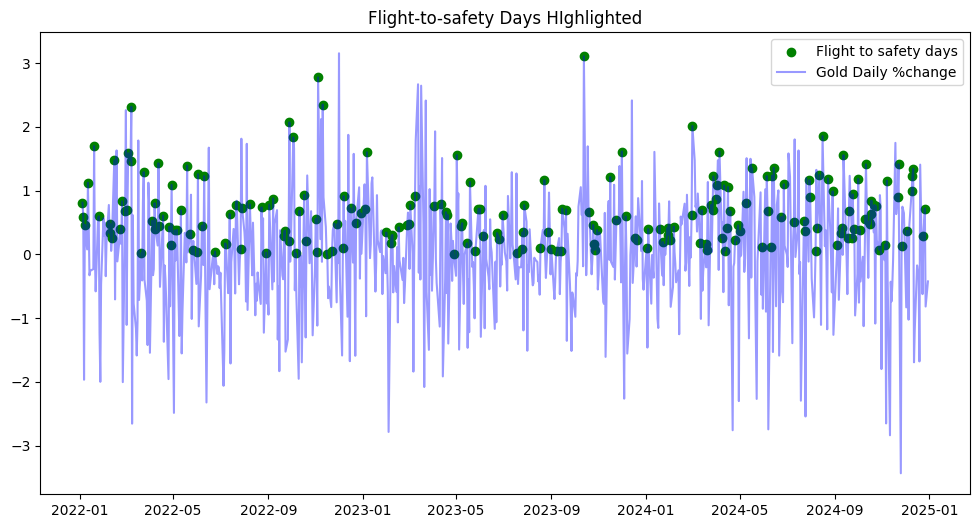

In [24]:
plt.figure(figsize=(12,6))
plt.scatter(flight_days.index, flight_days["GC=F_pct_change"],color ='green', label ='Flight to safety days',marker='o')
plt.plot(df['GC=F_pct_change'],alpha = 0.4, label='Gold Daily %change', color='blue')
plt.title("Flight-to-safety Days HIghlighted")
plt.legend()
plt.show()

In [25]:
flight_days[["GC=F_pct_change","EURUSD=X_pct_change"]].describe()


,GC=F_pct_change,EURUSD=X_pct_change
count,204.000000,204.000000
mean,0.670135,-0.369212
std,0.538667,0.317605
min,0.010048,-1.841790
25%,0.292744,-0.520144
50%,0.558258,-0.290717
75%,0.905782,-0.135385
max,3.108114,-0.002170


In [32]:
flight_days.loc[:,"year"]=flight_days.index.year
flight_days["year"].value_counts().sort_index()

year
2022    71
2023    52
2024    81
Name: count, dtype: int64

2022-02-24found
2023-03-10 not found in flight_days


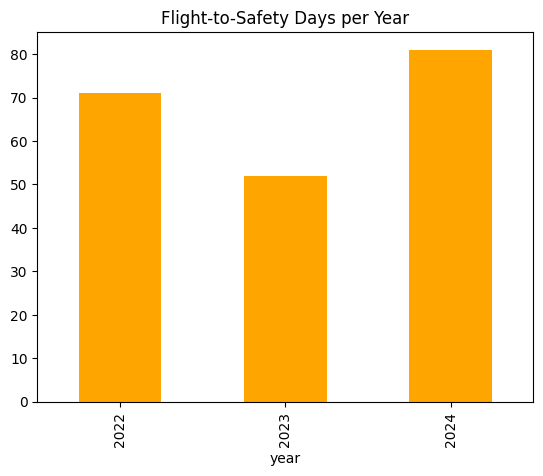

In [38]:
flight_days['year'].value_counts().sort_index().plot(kind='bar',title='Flight-to-Safety Days per Year', color='orange')
important_dates=['2022-02-24','2023-03-10']
for date in important_dates:
    if date in flight_days.index:
        print(f"{date}found")
    else:
        print(f"{date} not found in flight_days")


In [ ]:
### Flight-to-Safety Analysis Summary

This chart shows the number of "Flight-to-Safety" days per year — when Gold prices rose while EUR/USD fell.

- In **2022**, heightened geopolitical uncertainty (e.g., Ukraine invasion in February) triggered frequent capital flows into gold.
- In **2023**, fewer such days were observed, despite events like the SVB collapse in March, suggesting a relatively calmer macroeconomic environment.
- In **2024**, there's a clear increase again, possibly due to inflation fears, rate changes, or geopolitical tensions.

This supports the theory that gold serves as a haven asset in periods of global stress.
